In [1]:
import uproot, glob
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import os, glob, pickle
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep
from sklearn.metrics import auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
plt.style.use([hep.style.ROOT, hep.style.firamath])
from matplotlib.colors import LinearSegmentedColormap
import scipy
from scipy.stats import norm
# Define the CMS color scheme
cms_colors = [
    (0.00, '#FFFFFF'),  # White
    (0.33, '#005EB8'),  # Blue
    (0.66, '#FFDD00'),  # Yellow
    (1.00, '#FF0000')   # red
]

# Create the CMS colormap
cms_cmap = LinearSegmentedColormap.from_list('CMS', cms_colors)

mkdir -p failed for path /uscms_data/d1/bbbam/.cache/matplotlib: [Errno 30] Read-only file system: '/uscms_data'
Matplotlib created a temporary cache directory at /tmp/matplotlib-lx5qnvz3 because there was an issue with the default path (/uscms_data/d1/bbbam/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# out_dir='data/plot_H_AA_4Tau_M_10_signal_kinematics'
out_dir='../analysis_run3/AN_Note_Plot/classifier_miniAOD'
if not os.path.isdir(out_dir):
    os.makedirs(out_dir)
save = True


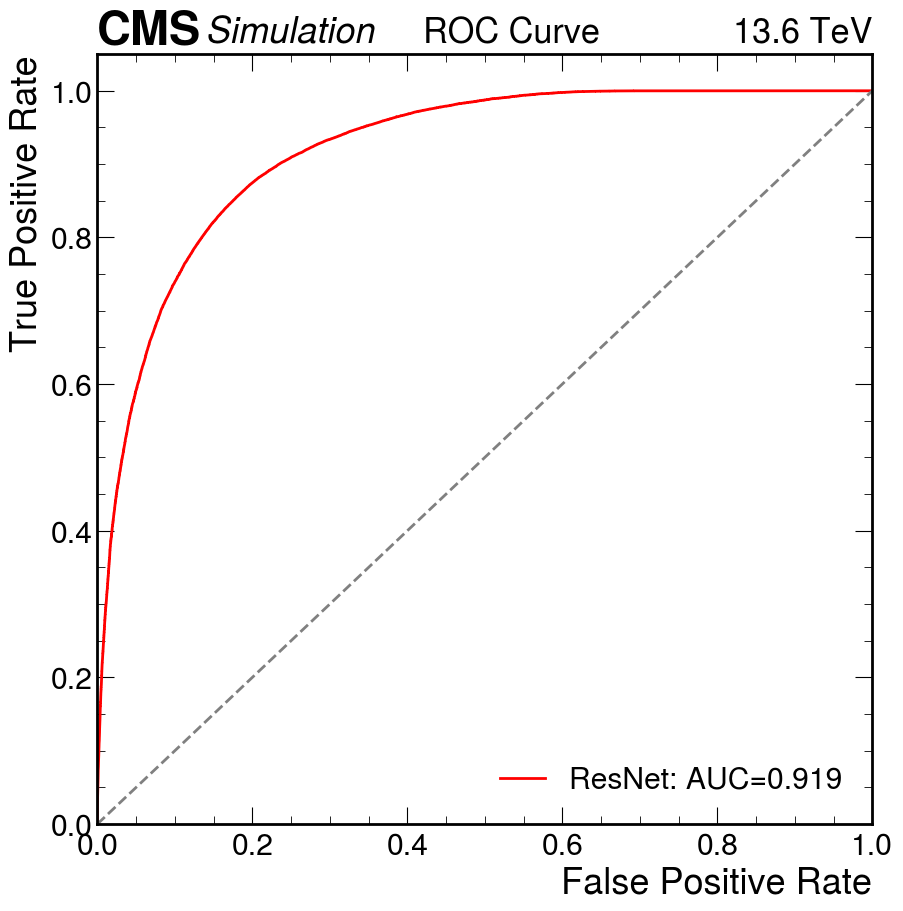

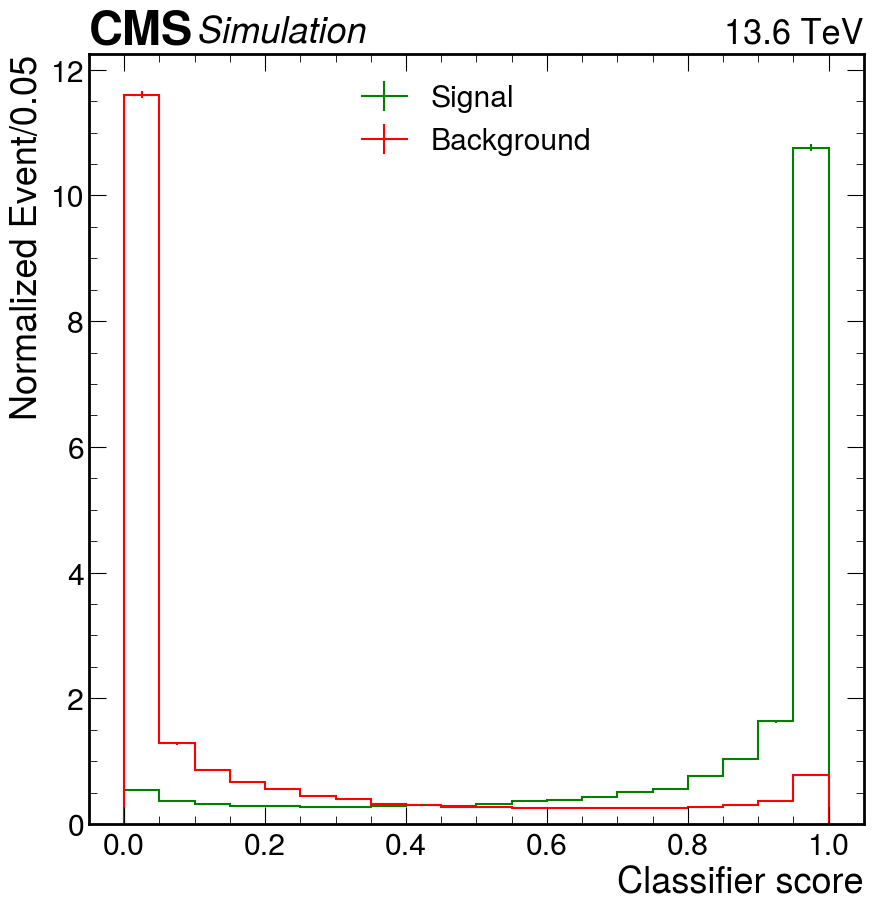

Accuracy: 83.71%
Precision: 83.68%
Recall: 83.83%
F1 Score: 83.75%
Confusion Matrix:
[[54423 10678]
 [10561 54748]]


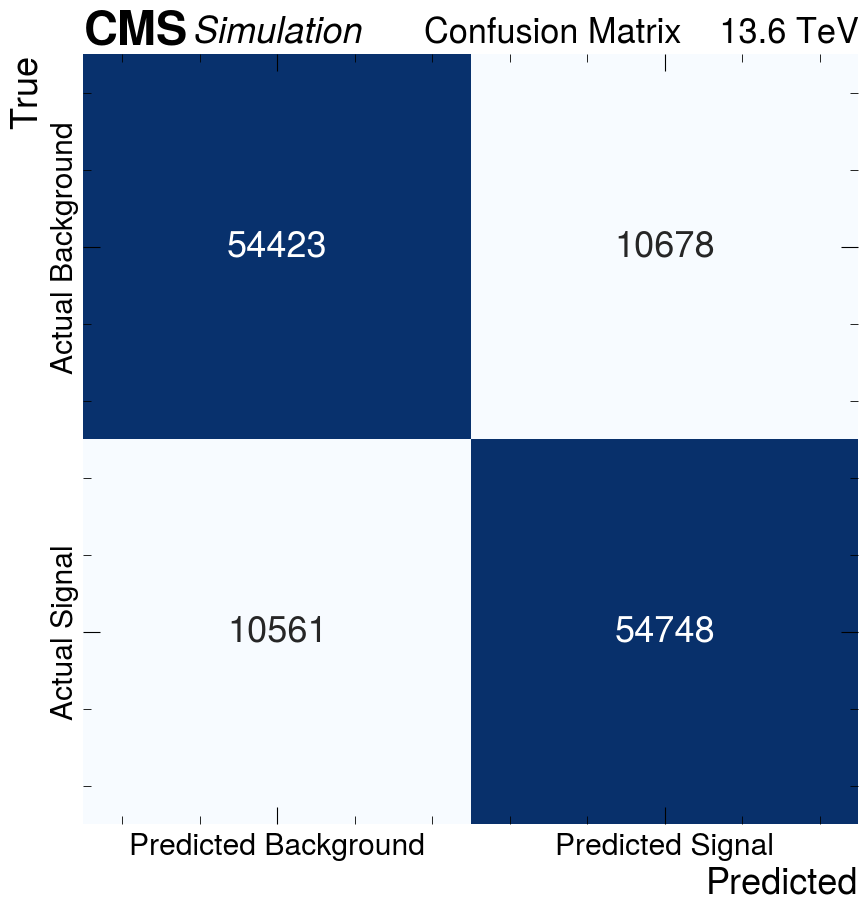

In [15]:

dpi_=100
epoch=100

data_dir ='../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD'
model_dir = '5_ch_classifier_ResNet_mapA'

bins = np.arange(0,1.01,0.05)
data_file = glob.glob(f"{data_dir}/{model_dir}/INFERENCE_DATA/epoch{epoch}_auc*.pkl")[0]
# print(data_file)
infile = open(f"{data_file}", "rb")
data = pickle.load(infile)
fpr = data['fpr'] 
tpr = data['tpr']

fig, ax = plt.subplots(dpi=dpi_)
plt.plot(fpr, tpr, color='red', lw=2, label=f'ResNet: AUC={np.round(auc(fpr, tpr),3)}', rasterized=True)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
hep.cms.label(llabel="Simulation ", rlabel="ROC Curve         " + "     13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/roc_curve_resnet_mapA_model_miniAOD_validation.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()



sig , back = [], []
bins = np.arange(0,1.01,0.05)
y_pred = data['y_pred'].flatten()
y_true = data['y_true'].flatten()

for i in range(len(y_true)):
    if y_true[i]==1: 
        sig.append(y_pred[i])
    else:
        back.append(y_pred[i])
fig, ax = plt.subplots(dpi=dpi_)

h1_counts, h1_bins = np.histogram(sig, bins=bins)
hep.histplot(h1_counts, h1_bins, histtype='step', yerr=True,
             label='Signal', linestyle='-', color='g', density=True, rasterized=True)
h2_counts, h2_bins = np.histogram(back, bins=bins)
hep.histplot(h2_counts, h2_bins, histtype='step', yerr=True,
             label='Background', linestyle='-', color='r', density=True, rasterized=True)

plt.xlabel('Classifier score')
plt.ylabel('Normalized Event/0.05')
plt.legend(loc='best')
hep.cms.label(llabel="Simulation ", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/classifier_score_for_resnet_mapA_model_miniAOD_validation.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()


# Convert probabilities to binary predictions
y_pred_binary = (y_pred >= 0.5).astype(int)

# Calculate accuracy
accuracy = accuracy_score(y_true, y_pred_binary)
print(f"Accuracy: {accuracy:.2%}")

# Calculate precision
precision = precision_score(y_true, y_pred_binary)
print(f"Precision: {precision:.2%}")

# Calculate recall
recall = recall_score(y_true, y_pred_binary)
print(f"Recall: {recall:.2%}")

# Calculate F1 score
f1 = f1_score(y_true, y_pred_binary)
print(f"F1 Score: {f1:.2%}")

# Confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(conf_matrix)
fig, ax = plt.subplots(dpi=dpi_)
# Plot confusion matrix heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Background', 'Predicted Signal'],
            yticklabels=['Actual Background', 'Actual Signal'], rasterized=True)

plt.ylabel('True')
plt.xlabel('Predicted')
hep.cms.label(llabel="Simulation ", rlabel="Confusion Matrix  "+"  13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/confusion_matrix_for_resnet_mapA_model_miniAOD_validation.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()


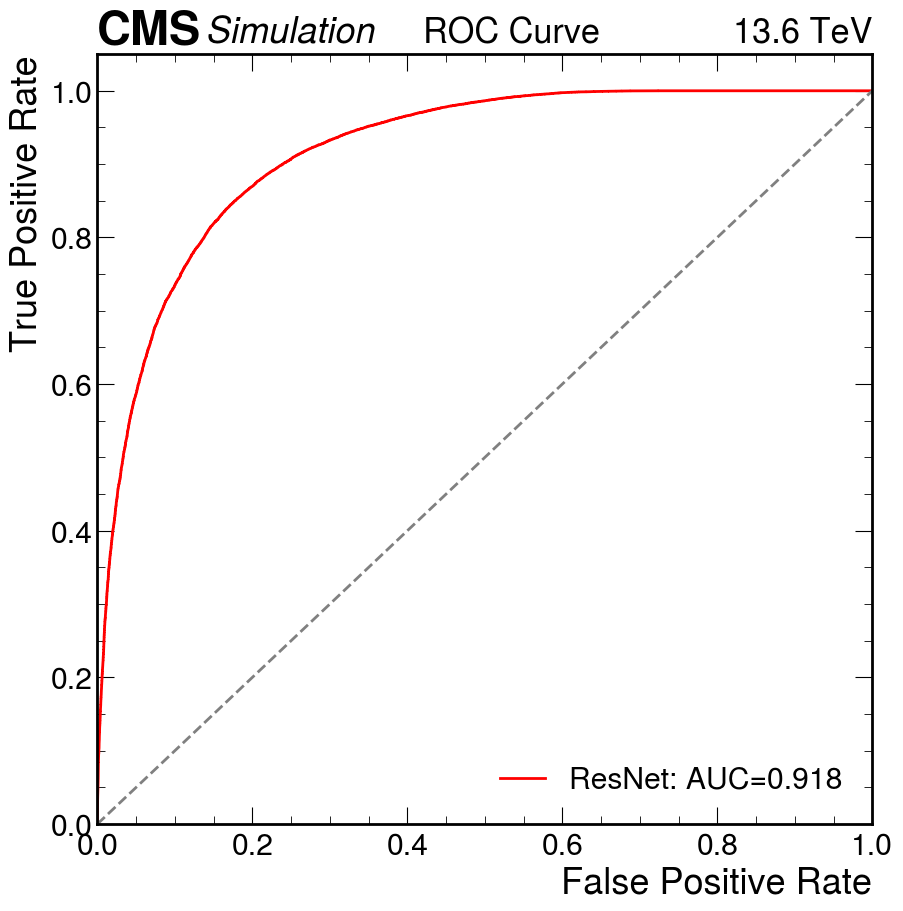

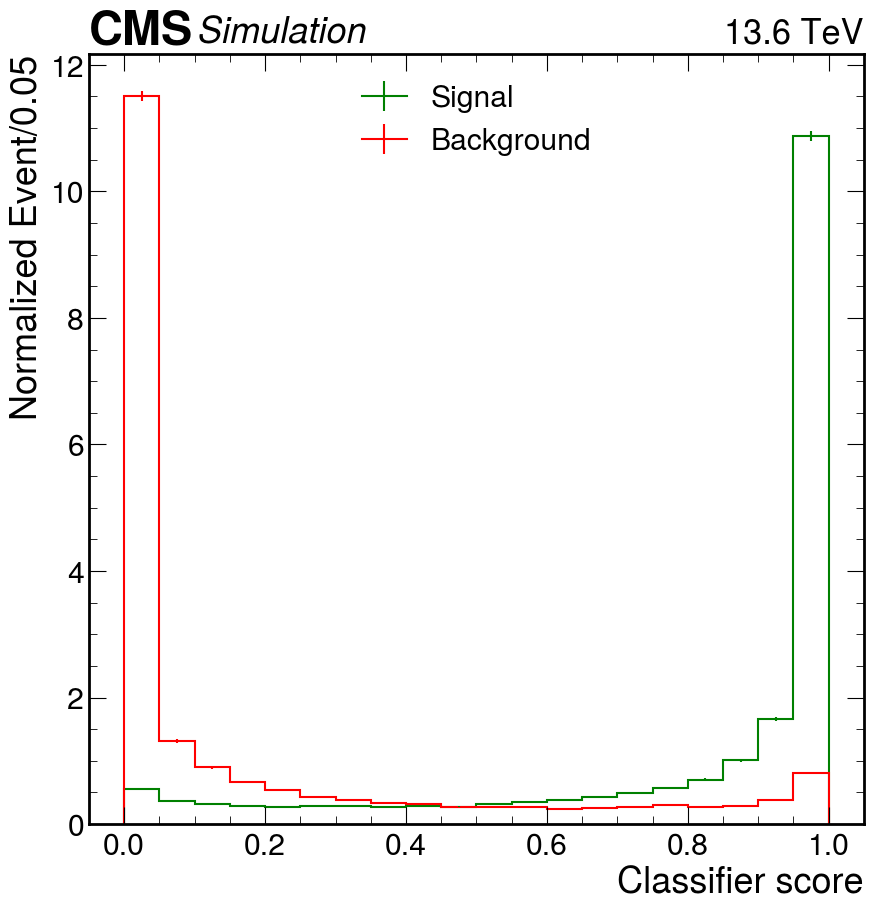

Accuracy: 83.59%
Precision: 82.53%
Recall: 84.01%
F1 Score: 83.27%
Confusion Matrix:
[[31955  6457]
 [ 5807 30513]]


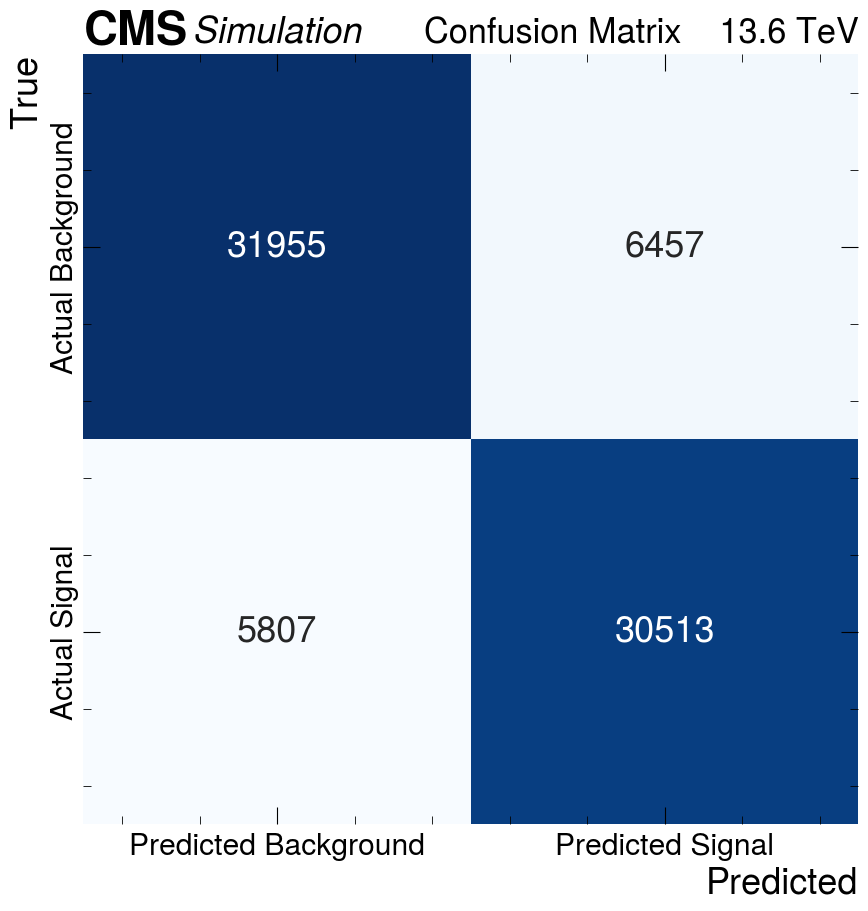

In [20]:
from sklearn.metrics import roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

dpi_=100

data_dir ='../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD'
model_dir = '5_ch_classifier_ResNet_mapA_test'
bins = np.arange(0,1.01,0.05)
data_file = glob.glob(f"{data_dir}/{model_dir}/IMG_signal_background_combined_valid_test_data.pkl")[0]
# print(data_file)
infile = open(f"{data_file}", "rb")
data = pickle.load(infile)

# --- Read y_true / y_pred and flatten ---
y_pred = data['y_pred'].flatten()
y_true = data['y_true'].flatten()

# --- Compute ROC curve from raw scores ---
fpr, tpr, thresholds = roc_curve(y_true, y_pred)

fig, ax = plt.subplots(dpi=dpi_)
plt.plot(fpr, tpr, color='red', lw=2, label=f'ResNet: AUC={np.round(auc(fpr, tpr),3)}', rasterized=True)
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
hep.cms.label(llabel="Simulation ", rlabel="ROC Curve         " + "     13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/roc_curve_resnet_mapA_model_miniAOD_test_dataset.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

# --- Classifier score histograms ---
sig , back = [], []
bins = np.arange(0,1.01,0.05)
for i in range(len(y_true)):
    if y_true[i]==1:
        sig.append(y_pred[i])
    else:
        back.append(y_pred[i])

fig, ax = plt.subplots(dpi=dpi_)
h1_counts, h1_bins = np.histogram(sig, bins=bins)
hep.histplot(h1_counts, h1_bins, histtype='step', yerr=True,
             label='Signal', linestyle='-', color='g', density=True, rasterized=True)
h2_counts, h2_bins = np.histogram(back, bins=bins)
hep.histplot(h2_counts, h2_bins, histtype='step', yerr=True,
             label='Background', linestyle='-', color='r', density=True, rasterized=True)
plt.xlabel('Classifier score')
plt.ylabel('Normalized Event/0.05')
plt.legend(loc='best')
hep.cms.label(llabel="Simulation ", rlabel="13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/classifier_score_for_resnet_mapA_model_miniAOD_test_dataset.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

# --- Metrics ---
y_pred_binary = (y_pred >= 0.5).astype(int)
accuracy = accuracy_score(y_true, y_pred_binary)
print(f"Accuracy: {accuracy:.2%}")

precision = precision_score(y_true, y_pred_binary)
print(f"Precision: {precision:.2%}")

recall = recall_score(y_true, y_pred_binary)
print(f"Recall: {recall:.2%}")

f1 = f1_score(y_true, y_pred_binary)
print(f"F1 Score: {f1:.2%}")

conf_matrix = confusion_matrix(y_true, y_pred_binary)
print("Confusion Matrix:")
print(conf_matrix)

fig, ax = plt.subplots(dpi=dpi_)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Background', 'Predicted Signal'],
            yticklabels=['Actual Background', 'Actual Signal'], rasterized=True)
plt.ylabel('True')
plt.xlabel('Predicted')
hep.cms.label(llabel="Simulation ", rlabel="Confusion Matrix  "+"  13.6 TeV", loc=0, ax=ax)
# plt.savefig(f'{out_dir}/confusion_matrix_for_resnet_mapA_model_miniAOD_test_dataset.pdf', bbox_inches='tight',dpi=300, facecolor = "w")
plt.show()

Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_signal_mass_3p7_GeV_miniAOD_combined_seperately_valid_test_data.pkl
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_signal_mass_4_GeV_miniAOD_combined_seperately_valid_test_data.pkl
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_signal_mass_5_GeV_miniAOD_combined_seperately_valid_test_data.pkl
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_signal_mass_6_GeV_miniAOD_combined_seperately_valid_test_data.pkl
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_signal_mass_8_GeV_miniAOD_combined_seperately_valid_test_data.pkl
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_background_QCD

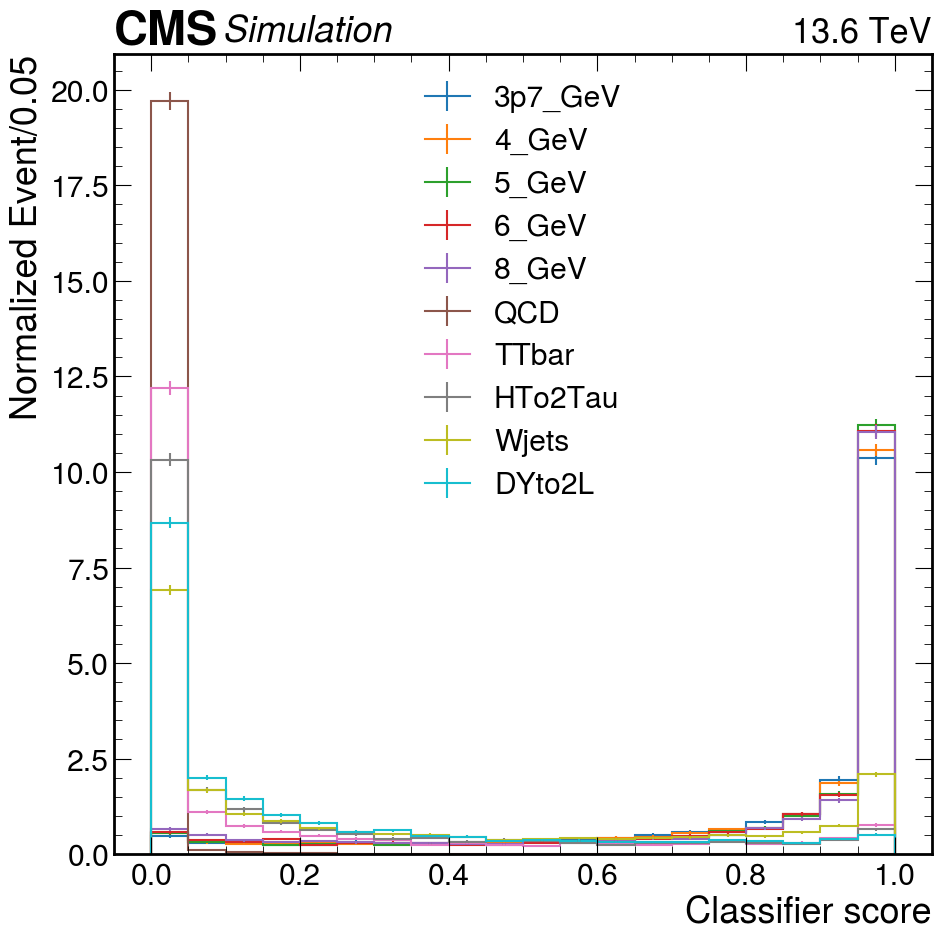

In [30]:
bins = np.arange(0, 1.01, 0.05)
data_dir = '../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD'
model_dir = '5_ch_classifier_ResNet_mapA_test'

label = ['3p7_GeV', '4_GeV', '5_GeV', '6_GeV', '8_GeV',
         'QCD', 'TTbar', 'HTo2Tau', 'Wjets', 'DYto2L']

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple',
    'tab:brown',
    'tab:pink',
    'tab:gray',
    'tab:olive',
    'tab:cyan'
]

fig, ax = plt.subplots(dpi=100)

for i, tag in enumerate(label):
    file_list = glob.glob(f"{data_dir}/{model_dir}/IMG*{tag}*.pkl")
    if not file_list:
        print(f"No file found for {tag}")
        continue

    data_file = file_list[0]
    print("Loading:", data_file)

    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    y_pred = data['y_pred'].flatten()

    h1_counts, h1_bins = np.histogram(y_pred, bins=bins)
    hep.histplot(
        h1_counts, h1_bins,
        histtype='step',
        yerr=True,
        label=tag,
        linestyle='-',
        color=colors[i],
        density=True
    )

ax.set_xlabel('Classifier score')
ax.set_ylabel('Normalized Event/0.05')
ax.legend(loc='best')
hep.cms.label(llabel="Simulation ", rlabel="13.6 TeV", loc=0, ax=ax)
plt.tight_layout()
# plt.savefig(f'{out_dir}/classifier_score_for_resnet_mapA_model_minoAOD_all_sig_back.pdf', bbox_inches='tight', dpi=300, facecolor="w")
plt.show()

Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_background_QCD_miniAOD_combined_seperately_valid_test_data.pkl
[1.9078934e-06 8.5827523e-09 5.0885780e-16 ... 3.5803655e-19 1.8499034e-11
 5.8243778e-08]
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_background_TTbar_miniAOD_combined_seperately_valid_test_data.pkl
[4.0732262e-09 2.2330892e-03 1.4553141e-14 ... 1.6216855e-01 3.0959040e-02
 5.9002028e-05]
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_background_HTo2Tau_miniAOD_combined_seperately_valid_test_data.pkl
[1.26065675e-14 1.30956468e-16 6.59107168e-14 ... 8.80650654e-02
 4.94663596e-01 3.75329696e-17]
Loading: ../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD/5_ch_classifier_ResNet_mapA_test/IMG_background_Wjets_miniAOD_combined_seperately_valid_test_data.pkl
[0.01253383 0.11869603 0.

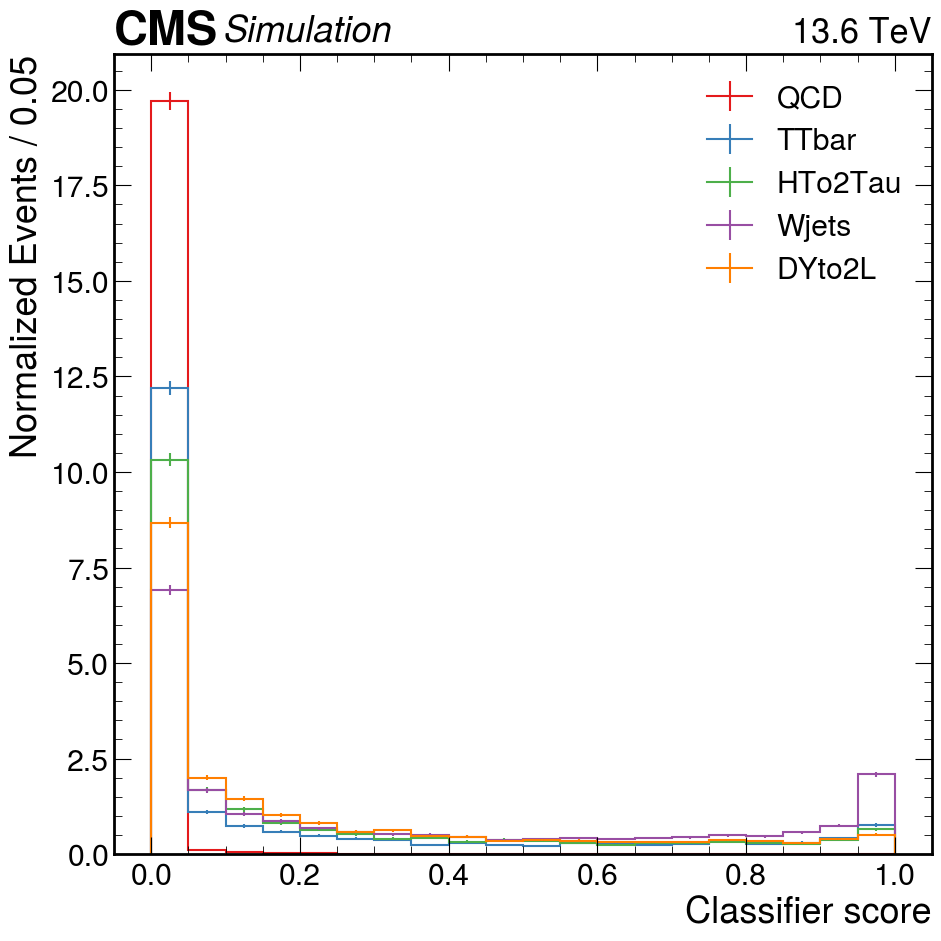

In [31]:


bins = np.arange(0, 1.01, 0.05)

data_dir ='../analysis_run3/Data_for_plots/ResNet_mapA_classifier_miniAOD'
model_dir = '5_ch_classifier_ResNet_mapA_test'
# labels = ['3p7_GeV', '4_GeV', '5_GeV', '6_GeV', '8_GeV']
labels = ['QCD', 'TTbar', 'HTo2Tau', 'Wjets', 'DYto2L']
# labels = ["QCD"]
colors = plt.cm.Set1.colors # safer automatic colors

fig, ax = plt.subplots(dpi=100)

for i, tag in enumerate(labels):

    file_list = glob.glob(f"{data_dir}/{model_dir}/IMG*{tag}*.pkl")

    if not file_list:
        print(f"No file found for {tag}")
        continue

    data_file = file_list[0]
    print("Loading:", data_file)

    with open(data_file, "rb") as infile:
        data = pickle.load(infile)

    y_pred = data['y_pred'].flatten()
    y_true = data['y_true'].flatten()
    print(y_pred[y_pred > 0])
    h1_counts, h1_bins = np.histogram(y_pred, bins=bins)

    hep.histplot(
        h1_counts,
        h1_bins,
        histtype='step',
        yerr=True,
        label=tag,
        linestyle='-',
        color=colors[i],
        density=True
    )

ax.set_xlabel('Classifier score')
ax.set_ylabel('Normalized Events / 0.05')
ax.legend(loc='best')

hep.cms.label(llabel="Simulation", rlabel="13.6 TeV", loc=0, ax=ax)

plt.tight_layout()
# plt.savefig(f'{out_dir}/classifier_score_for_resnet_mapA_model_minoAOD_all_back.pdf', bbox_inches='tight', dpi=300, facecolor="w")
plt.show()